# Clade A results

In [55]:
import os
from datetime import datetime
save_res = True

In [56]:
# Create a folder for results:
if save_res:
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    output_directory = f"res/elfi_res/A_results/clade_A_{timestamp}/"
    os.makedirs(output_directory)
    print(f"Created a result directory: {output_directory}")

Created a result directory: res/elfi_res/A_results/clade_A_2024-01-04_14-48-01/


In [57]:
# Load the correct grid parameters:
import importlib
!cp grid_params_clade_A.py grid_params.py

# Write grid params to file:
with open("grid_params.py", 'r') as f:
    grid_pars = f.read()
    
with open(os.path.join(output_directory, "grid_params.py"), 'w') as f:
    f.write(grid_pars)

In [58]:
# Import elfi_model.py
 
import elfi_model
importlib.reload(elfi_model)
from elfi_model import *


Loading BSI_functions.py
Grid parameters:
Clade: A
Number of weeks to simulate: 728
Population size: 1000000
Year
2004     3.895481
2005     0.000395
2006    12.635743
2007     4.214390
2008    10.536233
2009     5.791327
2010    15.351836
2011     8.640565
2012    23.632022
2013    31.851170
2014    30.044468
2015    10.125092
2016    20.251191
2017    21.300956
Name: A, dtype: float64
Model imported


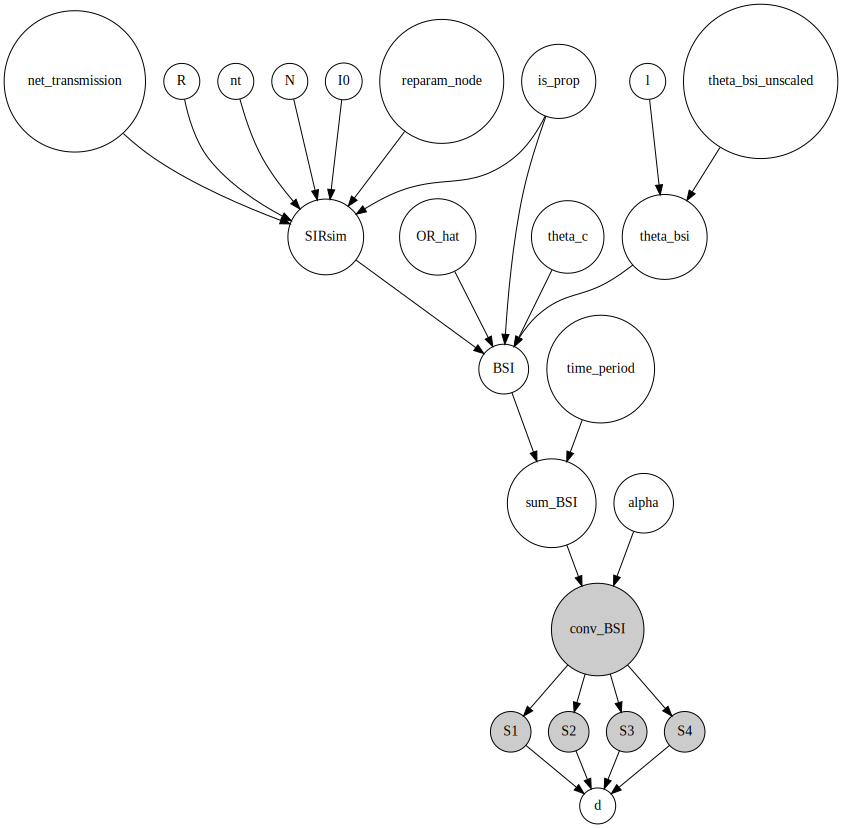

In [59]:
elfi.draw(m)

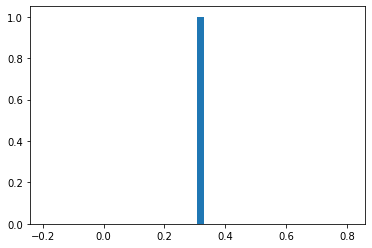

In [60]:
or_sample = OR_hat.generate(10000)

plt.hist(or_sample, bins = 50)
plt.show()

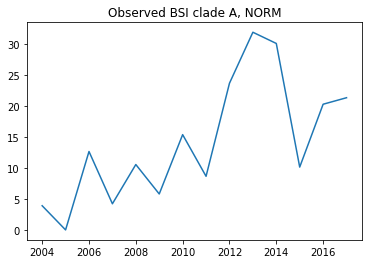

In [61]:
# Plot the observed data

plt.plot(bsi_obs_data)
plt.title(f"Observed BSI clade {clade}, {obs_data}")
plt.savefig(os.path.join(output_directory, "observed_BSI.pdf"), format="pdf", bbox_inches="tight")
plt.show()


## Visualizing the Prior

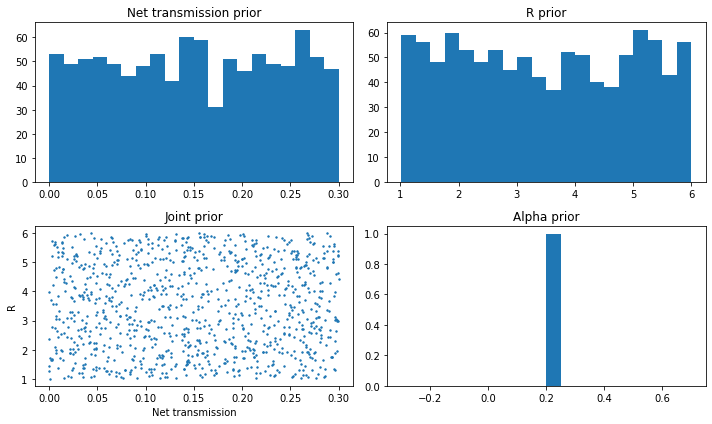

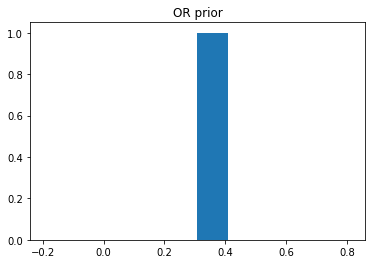

In [62]:
# Plot the priors
def plot_priors_elfi(par1 = "beta", par2 = "gamma"):
    # Plot priors from the elfi model. Currently supports only (beta, gamma) parametrisation.
    
    prior_sample =  m.generate(1000, outputs = [par1, par2])
    g = prior_sample[par2]
    b = prior_sample[par1]
    a_sample = alpha.generate(1000)


    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(b, bins=20)
    axs[0, 0].set_title(f'{par1} prior')
    axs[0, 1].hist(g, bins=20)
    axs[0, 1].set_title(f'{par2} prior')

    axs[1, 0].scatter(b,g, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel(f'{par1}')
    axs[1, 0].set_ylabel(f'{par2}')

    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, "priors.pdf"), format="pdf", bbox_inches="tight")
    plt.show()

    if not reparam:
        fig, axs = plt.subplots(1, 2, figsize=(10, 6))
        nt_sample = b - g
        R_sample = b/g
        axs[0].hist(nt_sample)
        axs[0].set_title("Corresponding net transmission")

        axs[1].hist(R_sample)
        axs[1].set_title("Corresponding R")
        plt.savefig(os.path.join(output_directory, "corresponding_R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
        plt.show()


        plt.scatter(nt_sample, R_sample, s=2)
        plt.title("Corresponding net transmission and R joint prior")
        plt.savefig(os.path.join(output_directory, "joint_R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
        plt.show()

if not reparam:    
    plot_priors_elfi()
else:
    net_sample = net_transmission.generate(1000)
    R_sample = R.generate(1000)
    a_sample = alpha.generate(1000)

    #print(R_sample.shape)
    #print(net_sample.shape)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(net_sample, bins=20)
    axs[0, 0].set_title('Net transmission prior')
    axs[0, 1].hist(R_sample, bins=20)
    axs[0, 1].set_title('R prior')
    
    axs[1, 0].scatter(net_sample, R_sample, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Net transmission')
    axs[1, 0].set_ylabel('R')
    
    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    filename = "nt_R_beta_priors.pdf"
    plt.savefig(os.path.join(output_directory, "R_nt_priors.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    
    or_sample = OR_hat.generate(1000)
    plt.hist(or_sample)
    plt.title("OR prior")
    plt.savefig(os.path.join(output_directory, "OR_prior.pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    

    

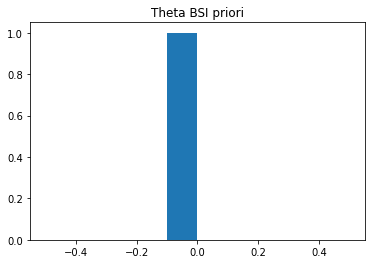

In [63]:
plt.hist(theta_bsi.generate(1000))
plt.title("Theta BSI prior")
plt.savefig(os.path.join(output_directory, "theta_BSI_prior.pdf"), format="pdf", bbox_inches="tight")
plt.show()

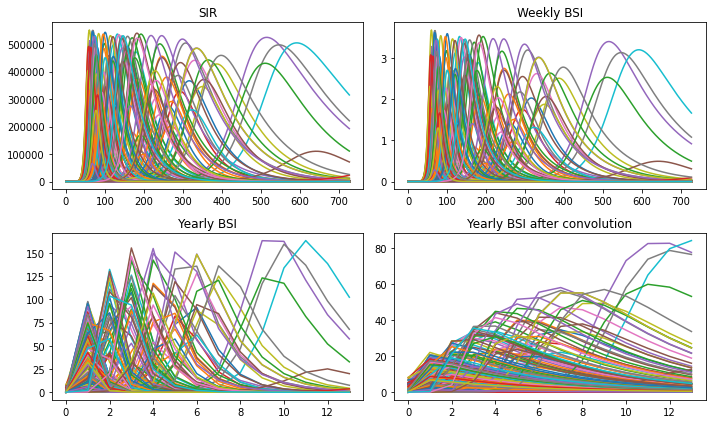

In [64]:
# Simulations from the prior:
sim_dict = m.generate(batch_size= 200, outputs = ["SIRsim", "BSI", "conv_BSI", "sum_BSI"])
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

axs[0, 0].plot(sim_dict["SIRsim"][1][0:200].T)
axs[0, 0].set_title(f'SIR')
axs[0, 1].plot(sim_dict["BSI"][0:200].T)
axs[0, 1].set_title(f'Weekly BSI')
axs[1, 0].plot(sim_dict["sum_BSI"][0:200].T)
axs[1, 0].set_title(f'Yearly BSI')
axs[1, 1].plot(sim_dict["conv_BSI"][0:200].T)
axs[1, 1].set_title(f'Yearly BSI after convolution')

plt.tight_layout()
plt.savefig(os.path.join(output_directory, "node_draws.pdf"), format="pdf", bbox_inches="tight")
plt.show()


Generating summary figures...
Done!


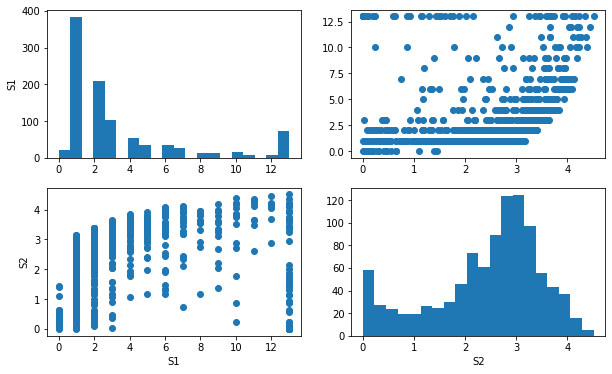

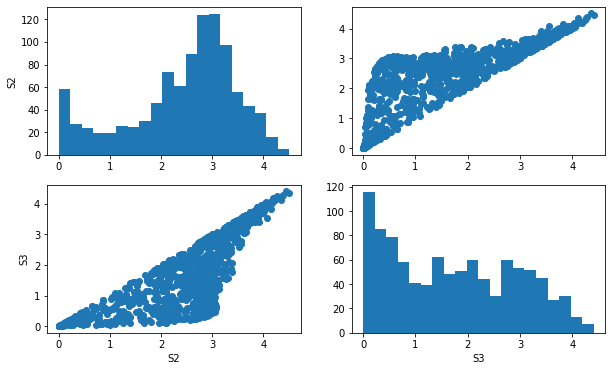

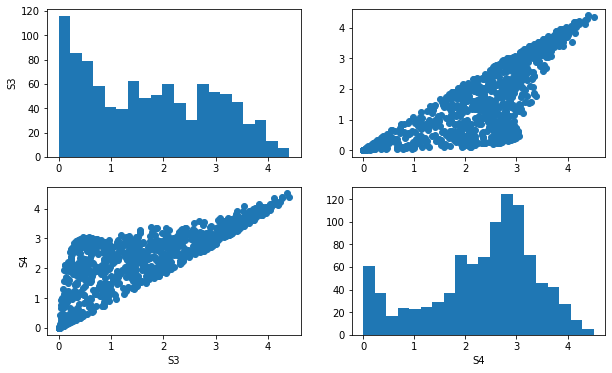

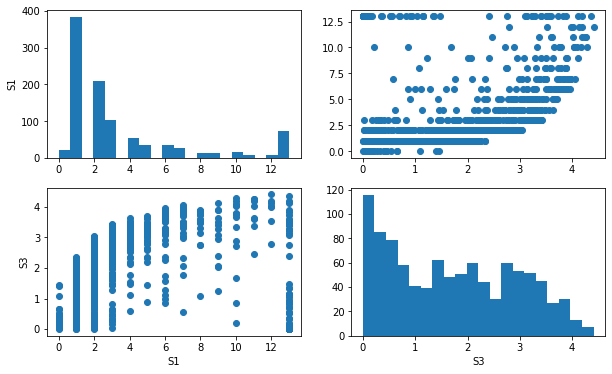

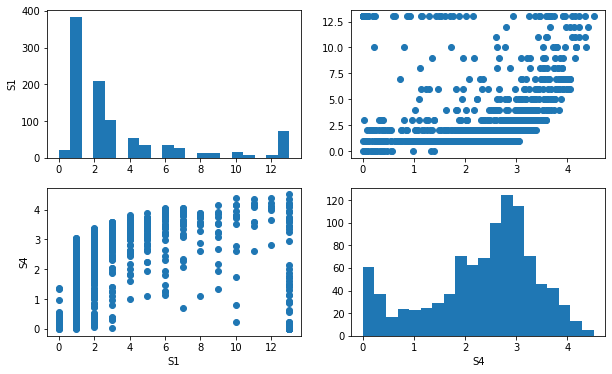

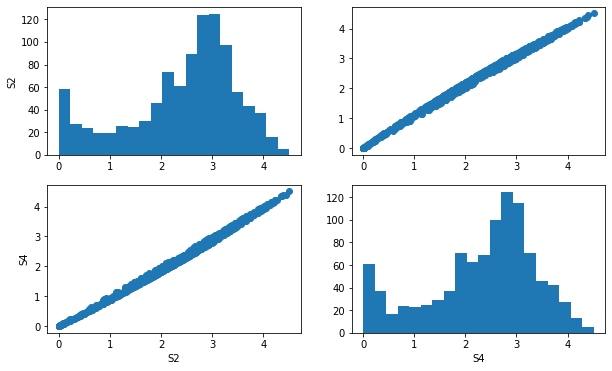

In [65]:
# Visualize summaries:
ssample = m.generate(1000, outputs = ["S1", "S2", "S3", "S4"])

def get_4x4_summaries(val1, val2, fname = "4x4_plot.pdf"):
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))


    axs[0, 0].hist(ssample[f'{val1}'], bins = 20)
    axs[0, 0].set_ylabel(f'{val1}')
    axs[0, 1].scatter(ssample[f'{val2}'], ssample[f'{val1}'])
    axs[1, 0].scatter(ssample[f'{val1}'], ssample[f'{val2}'])
    axs[1, 0].set_ylabel(f'{val2}')
    axs[1, 0].set_xlabel(f'{val1}')
    #axs[1, 0].set_title(f'S2 and S1')
    axs[1, 1].hist(ssample[f'{val2}'], bins = 20)
    axs[1, 1].set_xlabel(f'{val2}')
    
    plt.savefig(os.path.join(output_directory, fname), format="pdf", bbox_inches="tight")
    #plt.show()
    

print("Generating summary figures...")
get_4x4_summaries("S1", "S2", fname = "4x4_S1_S2_plot.pdf")
get_4x4_summaries("S2", "S3", fname = "4x4_S2_S3_plot.pdf")
get_4x4_summaries("S3", "S4", fname = "4x4_S3_S4_plot.pdf")
#get_4x4_summaries("S4", "S5", fname = "4x4_S4_S5_plot.pdf")
get_4x4_summaries("S1", "S3", fname = "4x4_S1_S3_plot.pdf")
get_4x4_summaries("S1", "S4", fname = "4x4_S1_S4_plot.pdf")
#get_4x4_summaries("S1", "S5", fname = "4x4_S1_S5_plot.pdf")
get_4x4_summaries("S2", "S4", fname = "4x4_S2_S4_plot.pdf")
#get_4x4_summaries("S2", "S5", fname = "4x4_S2_S5_plot.pdf")
#get_4x4_summaries("S3", "S5", fname = "4x4_S3_S5_plot.pdf")

print("Done!")


## Rejection Sampling

In [66]:
rej = elfi.Rejection(d, batch_size=100)
%time result = rej.sample(10000, quantile=0.01)

Progress [==================================================] 100.0% Complete
CPU times: user 3min 34s, sys: 2.9 s, total: 3min 37s
Wall time: 3min 34s


In [67]:
# Prior and posterior in the same figure
#pars_to_sample = ['OR_hat']
#pars_to_sample = ['theta_bsi']
pars_to_sample = ['alpha']
pars_to_sample = []

if reparam:
    par1 = "net_transmission"
    par2 = "R"
    
else:
    par1 = "beta"
    par2 = "gamma"
    

pars_to_sample.append(par1)
pars_to_sample.append(par2)

if not reparam:
    
    sample = m.generate(10000, pars_to_sample)
    
   

    # Beta or net transmission
    plt.hist(result.samples[par1], alpha = 0.5, label = "Posterior")
    plt.hist(sample[par1], alpha = 0.5, label = "Prior")
    plt.title(f"{par1} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # Gamma or R
    plt.hist(result.samples[par2], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample[par2], alpha = 0.5, label = "Prior", bins = 40)
    plt.title(f"{par2} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()
    
    # Joint prior: beta, gamma
    plt.scatter(result.samples[par1], result.samples[par2], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1], sample[par2], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par1} and {par2}")
    plt.xlabel(f"{par1}")
    plt.ylabel(f"{par2}")
    plt.legend(loc = "upper right")
    plt.show()

    try:
        # OR_hat

        plt.hist(result.samples['OR_hat'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['OR_hat'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("OR_hat posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("OR hat was not included as an estimated parameter.")

    try:
        # theta_bsi
        plt.hist(result.samples['theta_bsi'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['theta_bsi'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Theta_bsi posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("Theta_bsi was not included as an estimated parameter.")
        
    try:
        # OR_hat

        plt.hist(result.samples['alpha'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['alpha'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Alpha posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("Alpha was not included as an estimated parameter.")
    
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and OR_hat")
        plt.xlabel(f"{par1}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and OR_hat")
        plt.xlabel(f"{par2}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        pass
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and alpha")
        plt.xlabel(f"{par1}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and alpha")
        plt.xlabel(f"{par2}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        
        pass
    
    try:
        # Joint prior: par1, theta_bsi

        plt.scatter(result.samples[par1], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and theta_bsi")
        plt.xlabel(f"{par1}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: par2, theta_bsi

        plt.scatter(result.samples[par2], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and theta_bsi")
        plt.xlabel(f"{par2}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.show()
    
    except:
        pass
        
    try:   
        plt.scatter(result.samples[par1]/result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1]/sample[par2], sample['alpha'], alpha = 0.5, s = 2, label = "Prior")
        plt.title(f"Joint distribution of R0 and alpha")
        plt.xlabel("R0")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        pass

array([[<AxesSubplot: ylabel='R'>, <AxesSubplot: >],
       [<AxesSubplot: xlabel='R', ylabel='net_transmission'>,
        <AxesSubplot: xlabel='net_transmission'>]], dtype=object)

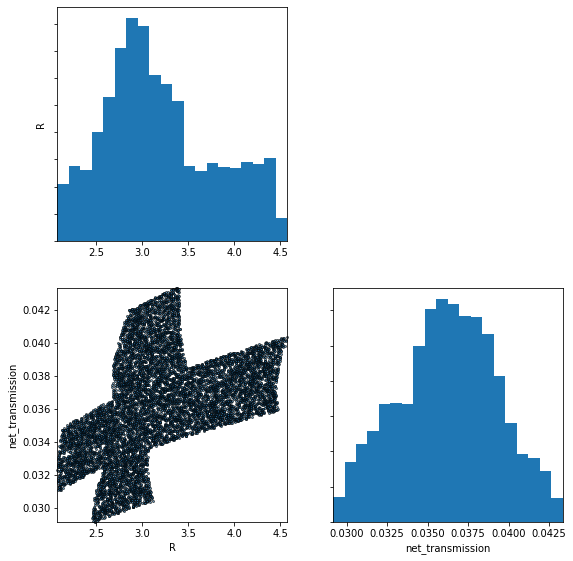

In [68]:
result.plot_pairs()

In [69]:
#np.median(result.samples['theta_bsi']) # 9.6e-6 would be the estimated median value for (nt, R)
# For (beta, gamma), 1.45e-5 and not really identifiable. Why though?

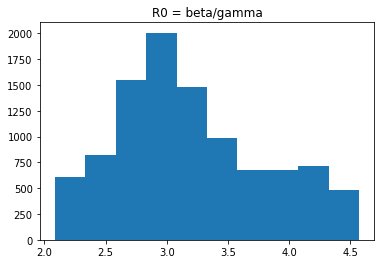

Mean of R: 3.1952208497434644
Median of R: 3.0844943856136493


In [70]:
# Plotting R0

if not reparam:
    R0 = result.samples['beta']/result.samples['gamma']
else:
    R0 = result.samples['R']

plt.hist(R0)
plt.title("R0 = beta/gamma")
plt.show()

print(f"Mean of R: {R0.mean()}")
print(f"Median of R: {np.median(R0)}")

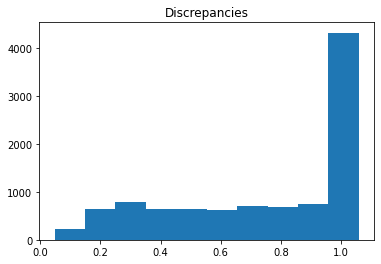

In [71]:
plt.hist(result.discrepancies)
plt.title("Discrepancies")
plt.show()

In [72]:
# Is discrepancy ordered? -> is this plot valid?

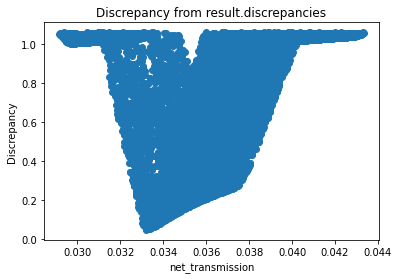

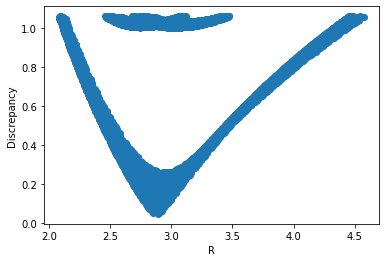

'\nplt.scatter(result.samples[\'OR_hat\'], result.discrepancies)\nplt.xlabel("OR")\nplt.ylabel("Discrepancy")\nplt.show()\n\n'

In [73]:
plt.scatter(result.samples[par1], result.discrepancies)
plt.title("Discrepancy from result.discrepancies")
plt.xlabel(f"{par1}")
plt.ylabel("Discrepancy")
plt.show()

plt.scatter(result.samples[par2], result.discrepancies)
plt.xlabel(f"{par2}")
plt.ylabel("Discrepancy")
plt.show()

"""
plt.scatter(result.samples['OR_hat'], result.discrepancies)
plt.xlabel("OR")
plt.ylabel("Discrepancy")
plt.show()

"""

## Posterior predictive check

In [74]:
OR_hat.generate(10)

0.3084

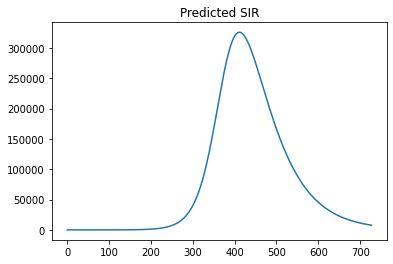

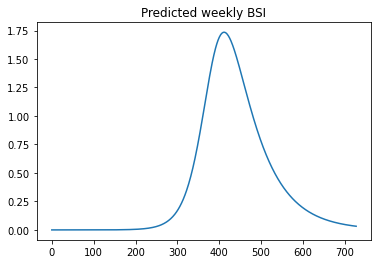

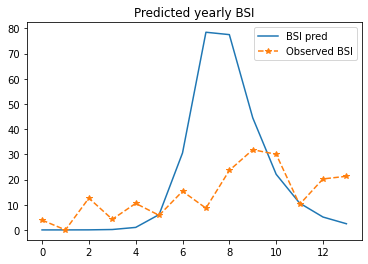

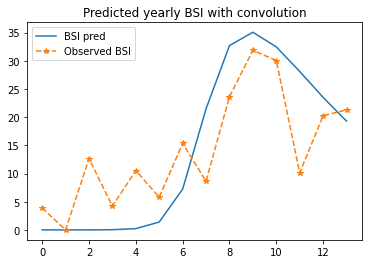

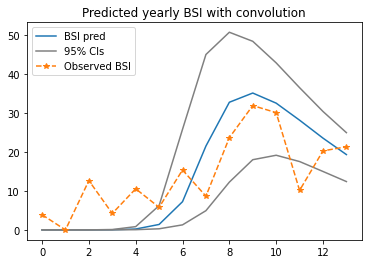

In [75]:
# Using elfi.generate

n_rep = 10 # Note: if OR hat is not fixed, we get different curves for each batch (they differ in height)

if reparam:
    par1 = "net_transmission"
    par2 = "R"
else:
    par1 = "beta"
    par2 = "gamma"

SIR_pred = SIRsim.generate(n_rep , with_values = {par1:np.mean(result.samples[par1]), par2:np.mean(result.samples[par2])}) # 10 samples, because then we can see 
    #if there's a mistake (more than 1 curve)
#"theta_bsi":np.mean(result.samples["theta_bsi"]), 
try:
    BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "OR_hat":np.mean(result.samples["OR_hat"])})
except: # OR was a constant
    BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "OR_hat":OR_hat.generate(1)})
BSI_yearly_pred = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred})

try:
    BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred, "alpha": np.mean(result.samples["alpha"])})
except:
    BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred})
    
plt.plot(SIR_pred[1].T)
plt.title("Predicted SIR")
plt.show()

plt.plot(BSI_pred.T)
plt.title("Predicted weekly BSI")
plt.show()


plt.plot(BSI_yearly_pred.T, label = "BSI pred")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI")
plt.legend()
plt.show()


plt.plot(BSI_conv_pred.T, label = "BSI pred")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI with convolution")
plt.legend()
plt.show()

# 95% credible intervals: nope - ei toimi.

ci = 95
par1_ci = np.percentile(result.samples[par1], [(100-ci)/2, 100 - (100-ci)/2])
par2_ci = np.percentile(result.samples[par2], [(100-ci)/2, 100 - (100-ci)/2])


# Lower:
SIR_pred_l = SIRsim.generate(n_rep , with_values = {par1:par1_ci[0], par2:par2_ci[0]})
try:
    BSI_pred_l = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_l, "OR_hat":np.mean(result.samples["OR_hat"])})
except:
    BSI_pred_l = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_l, "OR_hat":OR_hat.generate(1)})
BSI_yearly_pred_l = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred_l})


try:
    BSI_conv_pred_l = conv_BSI.generate(n_rep, with_values = {"sum_BSI":BSI_yearly_pred_l, "alpha": np.mean(result.samples["alpha"])})
except:
    BSI_conv_pred_l = conv_BSI.generate(n_rep, with_values = {"sum_BSI":BSI_yearly_pred_l})

# Upper:
SIR_pred_u = SIRsim.generate(n_rep, with_values = {par1:par1_ci[1], par2:par2_ci[1]})
try:
    BSI_pred_u = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_u, "OR_hat":np.mean(result.samples["OR_hat"])})
except:
    BSI_pred_u = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_u, "OR_hat":OR_hat.generate(1)})
BSI_yearly_pred_u = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred_u})

try:
    BSI_conv_pred_u = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred_u, "alpha": np.mean(result.samples["alpha"])})
except:
    BSI_conv_pred_u = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred_u})


plt.plot(BSI_conv_pred.T, label = "BSI pred")
plt.plot(BSI_conv_pred_u.T, label = f"{ci}% CIs", color = "grey")
plt.plot(BSI_conv_pred_l.T, color = "grey")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI with convolution")
plt.legend()
plt.show()
    



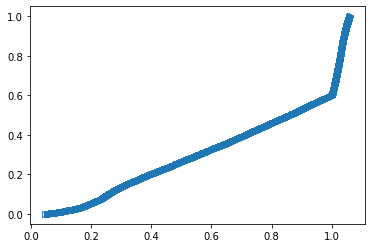

In [76]:
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/float(len(xs))
    return xs, ys

xs, ys = ecdf(result.discrepancies)
plt.plot(xs, ys, label="handwritten", marker=">", markerfacecolor='none')

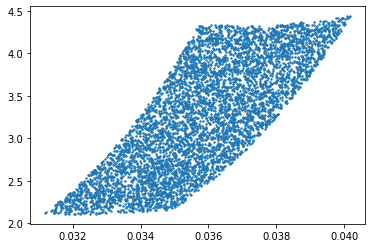

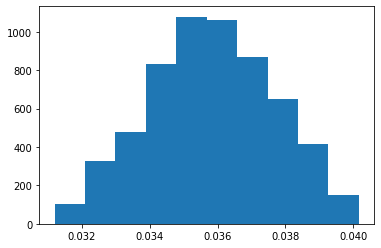

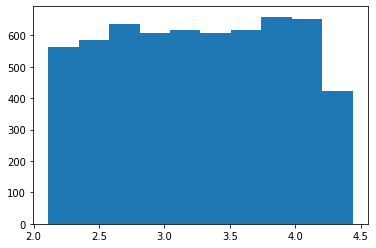

In [77]:
eps = 1
p1 = result.samples[par1][np.where(result.discrepancies < eps)]
p2 = result.samples[par2][np.where(result.discrepancies < eps)]

plt.scatter(p1, p2, s = 2) # Suspiciously regular?
plt.show()

plt.hist(p1)
plt.show()

plt.hist(p2) # (nt, R) parametrization: R not identifiable after the epsilon fix.
plt.show()

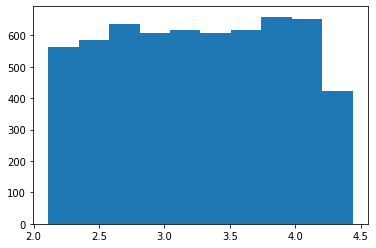

R mean: 3.2609773247546885
R median: 3.2665903042806645


In [78]:
if not reparam:
    plt.hist(p1/p2)
    plt.show()
    print(f"R0 mean: {np.mean(p1/p2)}")
    print(f"R0 median: {np.median(p1/p2)}")
else:
    plt.hist(p2)
    plt.show()
    print(f"R mean: {np.mean(p2)}")
    print(f"R median: {np.median(p2)}")
    

In [79]:
smc = elfi.SMC(d, batch_size=500, seed=1)
thresholds = [1., 0.5013, 0.2519, 0.1272, 0.0648, 0.0337, 0.0181, 0.0102, 0.0064, 0.0025]
smc_samples = smc.sample(1000, thresholds=thresholds)

ABC-SMC Round 1 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 2 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 3 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 4 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 5 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 6 / 10


KeyboardInterrupt: 

## Adaptive Threshold SMC

Problem: no logpdf for custom beta prior.


In [80]:
adaptive_smc = elfi.AdaptiveThresholdSMC(d, batch_size=100, seed=20243, q_threshold=0.995)
adaptive_smc_samples = adaptive_smc.sample(1000, max_iter=10)

ABC-SMC Round 1 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 2 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 3 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 4 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 5 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 6 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 7 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 8 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 9 / 10
Progress [==================================================] 100.0% Complete
ABC-SMC Round 10 / 10
Progress [==================================================] 100.0% Complete
